<div class="output_png output_subarea output_execute_result">
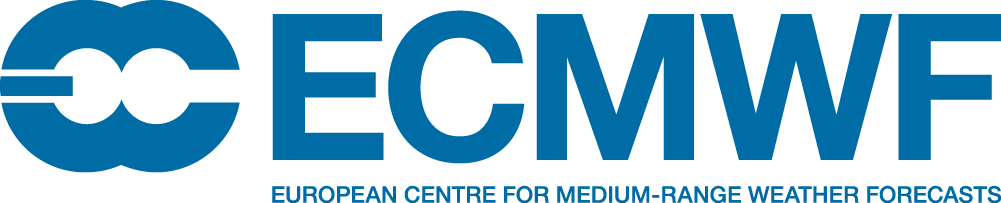
</div>

# 	Probabilities: 2 m dew point temperature

This notebook will provide you with guidance on how to explore and plot the ECMWF open dataset to produce the map from the ECMWF Open Charts web product.  
The original product can be found at this link: https://charts.ecmwf.int/products/medium-ens-2tdew 


<div class="output_png output_subarea output_execute_result">
<center>
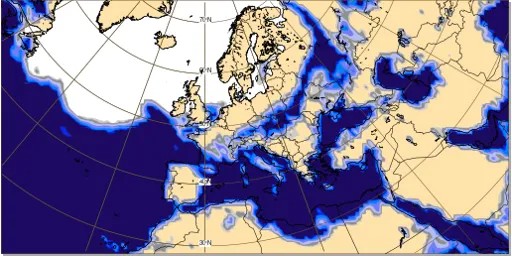</center>
</div>

The full list of available Open Data products can be found [here](https://www.ecmwf.int/en/forecasts/datasets/open-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF Open Data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain access to the full forecast dataset at higher resolution, please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes 1 parameter as input:

* [2 metre dewpoint temperature](https://codes.ecmwf.int/grib/param-db/168)

In this example, we will use: 
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data 

First, we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on the three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-opendata

In [1]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [ ]:
client = Client("ecmwf", beta=False)

In [3]:
parameters = ['2d']
filename1 = 'medium-ens-2tdew-pf.grib'
filename2 = 'medium-ens-2tdew-cf.grib'
filename1,filename2

('medium-ens-2tdew-pf.grib', 'medium-ens-2tdew-cf.grib')

We need to put **pf** as **type** and **enfo** as **stream** to download all 50 ensemble members. To download the control forecast, we put **fc** as **type** and **oper** as **stream**.  
To download individual members, please specify type="pf", and number=[1,2,3], or any list of desired members.

Setting "date" to 0 will download today's data. 
Removing "date" and "time" altogether from the request will download the latest data.  
Try commenting out the date and time to download the latest forecast!

In [4]:
client.retrieve(
 date=-1,
 time=0,
 step=24,
 stream="enfo",
 type="pf",
 levtype="sfc",
 param=parameters,
 target=filename1
)
client.retrieve(
 date=-1,
 time=0,
 step=24,
 stream="oper",
 type="fc",
 levtype="sfc",
 param=parameters,
 target=filename2
)

20260730000000-24h-enfo-ef.grib2:   0%|          | 0.00/32.7M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


20260730000000-24h-oper-fc.grib2:   0%|          | 0.00/664k [00:00<?, ?B/s]

## Reading and processing the data
Now we can use **Metview's read() function** to read the files.

In [5]:
data1 = mv.read(filename1)
data2 = mv.read(filename2)
data = mv.merge(data1,data2)

The **describe()** function will give us the overview of the dataset.  

In [6]:
data.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
2d,heightAboveGround,2,20260730,0,24,"1,10,...",168,od,"enfo,oper","fc,pf",0001


And an overview of one parameter

In [7]:
data.describe('2d')

shortName,2d
name,2 metre dewpoint temperature
paramId,168
units,K
typeOfLevel,heightAboveGround
level,2
date,20260730
time,0
step,24
number,"1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,45,46,47,48,49,5,50,6,7,8,9,None"
class,od


We can use **ls()** function to list all the fields in the file we downloaded.  
Note that this fieldset has all fields randomly arranged. You can see that if you look at the **number** column. These are ensemble member numbers.

In [8]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
Message,,,,,,,,,,
0,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,19,regular_ll
1,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,12,regular_ll
2,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,42,regular_ll
3,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,18,regular_ll
4,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,11,regular_ll
5,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,41,regular_ll
6,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,17,regular_ll
7,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,10,regular_ll
8,ecmf,2d,heightAboveGround,2,20260730,0,24,pf,16,regular_ll


The dewpoint temperature is given in Kelvin, we can convert it to Celsius.

In [9]:
d2 = data - 273.15

Then, we mask where the dewpoint temperature is greater than 0, 5, 10, 15 and 20 degrees C.  
This will set values to 1 where the dewpoint is above a threshold and 0 where it is below a threshold.

In [10]:
d2_mask0 = d2 > 0.
d2_mask5 = d2 > 5.
d2_mask10 = d2 > 10.
d2_mask15= d2 > 15.
d2_mask20 = d2 > 20.

In the end we calculate the probability for dewpoint being greater than a threshold by calculating mean of the fieldset.

In [11]:
d2_prob0 = mv.mean(d2_mask0) * 100.0
d2_prob5 = mv.mean(d2_mask5) * 100.0
d2_prob10 = mv.mean(d2_mask10) * 100.0
d2_prob15 = mv.mean(d2_mask15) * 100.0
d2_prob20 = mv.mean(d2_mask20) * 100.0

## Plotting the data
And finally, we can plot the data on the map. Let's plot the probabilities of dewpoint temperature being greater than 0, 10 and 20 degrees C.

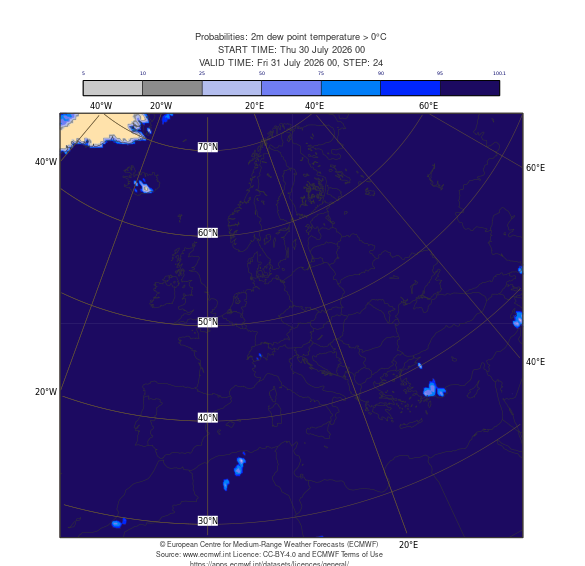

In [16]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
d2_prob_shade = mv.mcont(
    legend="on",
    contour="off",
    contour_highlight="off",
    contour_hilo="off",
    contour_label="off",
    contour_level_list=[5, 10, 25, 50, 75, 90, 95, 100.1],
    contour_level_selection_type="level_list",
    contour_shade="on",
    contour_shade_method="area_fill",
    contour_shade_colour_method="list",
    contour_shade_colour_list=["RGB(0.79,0.79,0.79)","RGB(0.55,0.55,0.55)","RGB(0.70,0.74,0.93)","RGB(0.44,0.49,0.95)","RGB(0.0,0.49,0.97)","RGB(0.0,0.15,0.99)","RGB(0.11,0.04,0.38)"],
)

title1 = mv.mtext(
    text_lines=["Probabilities: 2m dew point temperature > 0°C", 
           "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
           "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H'/>, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, d2_prob0, d2_prob_shade, title1, ecmwf_text)

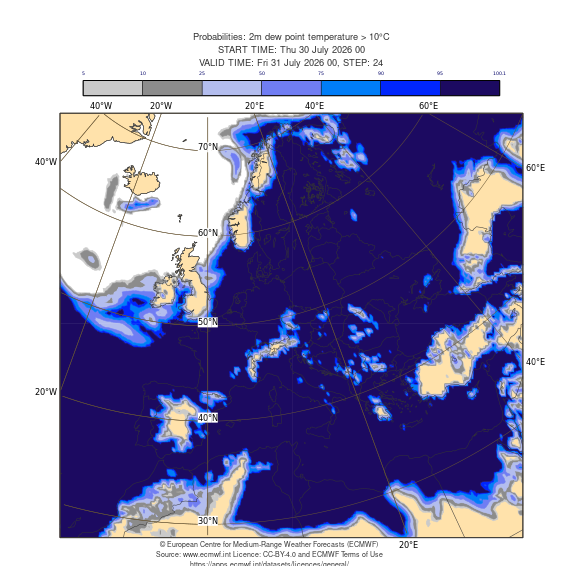

In [17]:
title2 = mv.mtext(
    text_lines=["Probabilities: 2m dew point temperature > 10°C", 
           "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
           "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H'/>, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')
# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, d2_prob10, d2_prob_shade, title2, ecmwf_text)

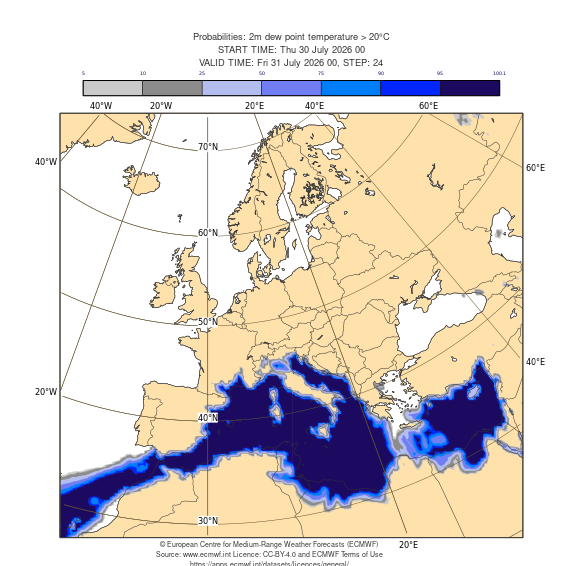

In [18]:
title3 = mv.mtext(
    text_lines=["Probabilities: 2m dew point temperature > 20°C", 
           "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
           "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H'/>, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')
# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, d2_prob20, d2_prob_shade, title3, ecmwf_text)

To generate the png file you can run the following cell.

In [21]:
png0 = mv.png_output(
      output_name = "medium-ens-2tdew-gt0",   # specify relative or full path
      output_title = "medium-ens-2tdew-0",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png0)
mv.plot(view, d2_prob0, d2_prob_shade, title1, ecmwf_text)

png10 = mv.png_output(
      output_name = "medium-ens-2tdew-gt10",   # specify relative or full path
      output_title = "medium-ens-2tdew-gt10",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png10)
mv.plot(view, d2_prob10, d2_prob_shade, title2, ecmwf_text)

png20 = mv.png_output(
      output_name = "medium-ens-2tdew-gt20",   # specify relative or full path
      output_title = "medium-ens-2tdew-gt20",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png20)
mv.plot(view, d2_prob20, d2_prob_shade, title3, ecmwf_text)

Note that the plot produced using the open data dataset will slightly differ from the one in Open Charts. This is due to the different resolution of the data.  
Open Data has a 0.25x0.25 resolution, while the high-resolution data has a 0.1x0.1 grid.